##  <font color="#117A65"><b>배송 소요 시간 예측</b></font>

### <font color="#5D6D7E"><b>목적</b></font>  
<b>배송 소요 시간을 예측</b>하여
물류 운영의 효율성을 높이고, 고객 만족도를 개선하기 위한
예측 모델을 구축합니다.

### <font color="#5D6D7E"><b>배경 시나리오</b></font>  
전자상거래 플랫폼을 운영하는 <b>B사</b>는 배송 지연으로 인한 고객 불만이 증가함에 따라 정확한 배송 시간 예측의 중요성이 커지고 있습니다.  
회사는 고객 주문 데이터와 배송 이력을 수집하여, 다양한 변수에 따른 <b>배송 소요 시간(delivery_time)</b>을 예측하는 모델을 구축하고자 합니다.  
이를 통해 예상 배송 일정을 사전에 고객에게 안내하고, 물류 리소스를 효율적으로 배분하려고 합니다.  

### 📊 <font color="#5D6D7E"><b>데이터 설명</b></font>
<b>파일 이름: delivery_time.csv</b>

데이터의 주요 컬럼은 다음과 같습니다.
| <b>컬럼명</b>             | <b>설명</b>                                                                 |
|--------------------------|------------------------------------------------------------------------------|
| `order_amount`           | 주문 금액 (단위: USD)                                   |
| `num_items`              | 주문한 아이템 개수                                          |
| `distance_km`            | 배달 거리 (단위: km)                                        |
| `rider_experience`       | 배달원 숙련도 (`low`, `medium`, `high`)                                     |
| `weather`                | 날씨 상태 (`sunny`, `cloudy`, `rain`, `storm`, `fog`)                        |
| `order_time`             | 주문 시간대 (`morning`, `afternoon`, `evening`, `night`)                     |
| `promotion_applied`      | 프로모션 적용 여부 (`Y`: 적용됨, `N`: 미적용)                                 |
| `delivery_time_min`      | <mark><b>실제 배달 소요 시간 (분)</b></mark> ← <b>예측 대상</b>               |


## [문제 1] 라이브러리 임포트

🖋 상황 설명  
배송 시간 예측을 위해 필요한 라이브러리를 임포트하려 합니다.  

🎯 목표  
- pandas, numpy, seaborn, matplotlib을 임포트하세요.

📑 조건  
- 순서대로 별칭(alias)은 pd, np, sns, plt로 지정

In [1]:
# 여기에 답안코드를 작성하세요.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mlp
import matplotlib.pyplot as plt

## [문제 2] 데이터 불러오기

🖋 상황 설명  
delivery_time.csv 파일을 불러와야 합니다.

🎯 목표
- 파일을 읽어 delivery_df라는 이름의 데이터프레임에 저장하세요.

📑 조건
- 파일명: delivery_time.csv

In [2]:
# 여기에 답안코드를 작성하세요.
delivery_df = pd.read_csv('./data/delivery_time.csv')

## [문제 3] 데이터 확인

🖋 상황 설명  
날씨상태(weather), 배달원 숙련도(rider_experience)에 따른 배달시간(deliverty_time_min)의 차이를 확인하고자 합니다.

🎯 목표  
- seaborn의 barplot()을 이용하여 시각화하고, 결과를 바탕으로 올바른 해석을 '답03'변수에 저장하세요.  
  
📑 조건
- x = weather
- y = delivery_time_min
- hue = rider_experience

  
1. snow 조건에서는 숙련도 간 차이가 가장 뚜렷하며, low 숙련도 라이더의 배송 시간이 다른 조건에 비해 가장 길다.  
2. rain 조건에서는 숙련도 간 차이가 가장 크고, high 숙련도 라이더가 유일하게 다른 날씨보다 느리게 배달했다.  
3. fog 조건에서는 숙련도가 높을수록 평균 배송 시간이 낮아지는 일관된 경향이 관찰된다.  
4. clear 조건에서는 숙련도 간의 차이가 가장 적고, 모든 그룹이 비슷한 평균 배송 시간을 기록했다.

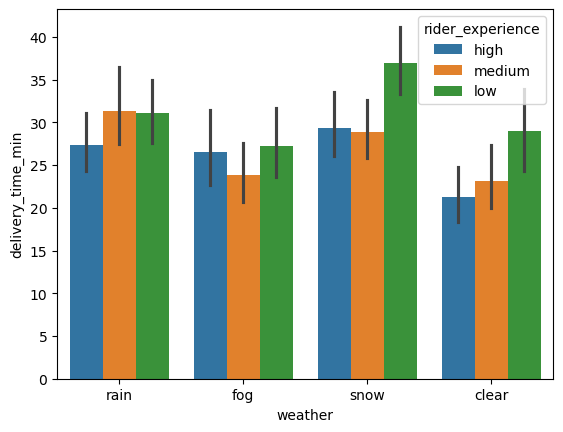

In [10]:
# 여기에 답안코드를 작성하세요.
sns.barplot(delivery_df, x='weather', y='delivery_time_min', hue='rider_experience', hue_order=['high', 'medium', 'low'])

답안03 = '1'

## [문제 4] 데이터 시각화에 따른 이상치 제거

🖋 상황 설명  
seaborn의 jointplot을 이용하여 배달시간(delivery_time_min)과 배달 거리(distance_km)간을 분석하고 이상치를 제거하고자 합니다.

🎯 목표
- x = distance_km
- y = delivery_time_min
- 시각화를 통해 데이터를 확인한 후, delivery_time이 100 이상인 이상치를 제거하고 del_df에 저장하세요.

##### 4-1 문제

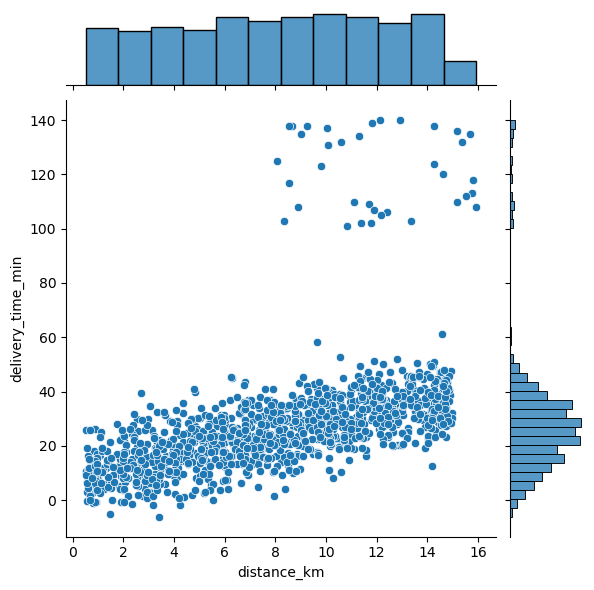

In [15]:
# 여기에 시각화 코드 답안을 작성하세요.
sns.jointplot(delivery_df, x='distance_km', y='delivery_time_min')

##### 4-2 문제

In [21]:
# 여기에 이상치 제거 코드를 작성하세요.
del_df = delivery_df[delivery_df['delivery_time_min'] <= 100].copy()

## [문제 5] 이상치 제거 및 인덱스 초기화

🖋 상황 설명  
del_df의 'delivery_time_min' 데이터에는 음수 값이 존재하고 있습니다. 이 음수 값들에 해당하는 데이터들을 삭제하고, index를 초기화 하세요.

🎯 목표
- axis=0, inplace=True
- reset_index()에서는 drop=True, inplace=True를 사용하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.
idx = del_df[del_df['delivery_time_min'] < 0].index
del_df.drop(index=idx, inplace=True, axis=0)
del_df.reset_index(drop=True, inplace=True)

## [문제 6] 필요없는 컬럼 제거

🖋 상황 설명  
'order_amount', 'num_items' 컬럼을 삭제합니다.

🎯 목표
- axis=1, inplace=True

In [25]:
# 여기에 답안코드를 작성하세요.
cols = ['order_amount', 'num_items']
del_df.drop(columns=cols, axis=1, inplace=True)

## [문제 7] 범주형 변수 인코딩

🖋 상황 설명  
rider_experience, weather, order_time 컬럼을 get_dummies로 변환하세요.

🎯 목표
- drop_first=True 옵션 사용
- 처리된 데이터는 encoding_df 변수에 저장하세요.

⚙ 주어진 코드

In [26]:
cat_col = ['rider_experience', 'weather', 'order_time']

위의 cat_col을 이용하여 원핫인코딩을 진행하세요.

In [28]:
# 여기에 답안코드를 작성하세요.
encoding_df = pd.get_dummies(del_df, columns=cat_col, drop_first=True)

## [문제 8] 이진 범주형 변수 인코딩

🖋 상황 설명  
이진값으로 이루어진 'promotion_applied'변수를 label encoding 하세요.(encoding_df에서 진행)

🎯 목표
- labelencoder 적용
- fit_transform을 사용하세요

⚙ 주어진 코드

In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [31]:
encoding_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   distance_km              1153 non-null   float64
 1   promotion_applied        1153 non-null   object 
 2   delivery_time_min        1153 non-null   float64
 3   rider_experience_low     1153 non-null   bool   
 4   rider_experience_medium  1153 non-null   bool   
 5   weather_fog              1153 non-null   bool   
 6   weather_rain             1153 non-null   bool   
 7   weather_snow             1153 non-null   bool   
 8   order_time_evening       1153 non-null   bool   
 9   order_time_morning       1153 non-null   bool   
 10  order_time_night         1153 non-null   bool   
dtypes: bool(8), float64(2), object(1)
memory usage: 36.2+ KB


In [33]:
# 여기에 답안코드를 작성하세요.
encoding_df['promotion_applied'] = le.fit_transform(encoding_df['promotion_applied'])

## [문제 9] train/test 데이터 분리

🖋 상황 설명  
모델 학습을 위해 feature(X)와 target(y)을 분리하고 평가를 위해 데이터를 8:2로 나눕니다.

🎯 목표
- 데이터 분리하기 위해 train_test_split을 불러오세요.
- X = delivery_time_min을 제외한 전부
- y = delivery_time_min  
- 훈련 데이터 셋 = X_train, y_train
- 검증 데이터 셋 = X_valid, y_valid
- 훈련데이터 셋과 검증 데이터셋의 비율은 8:2
- random_state=42

In [38]:
# 여기에 답안코드를 작성하세요.
from sklearn.model_selection import train_test_split
X = encoding_df.drop(columns=['delivery_time_min'])
y = encoding_df['delivery_time_min']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## [문제 10] 데이터 표준화

🖋 상황 설명  
StandardScaler를 이용하여 X_train과 X_valid를 표준화합니다.

🎯 목표
- StandardScaler를 불러오세요.
- X_train은 fit_tranform을 이용하여 X_train 변수에 저장
- X_valid는 transform을 이용하여 X_test의 변수에 저장

In [39]:
# 여기에 답안코드를 작성하세요.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

## [문제 11] 선형 회귀 모델 학습

🖋 상황 설명  
LinearRegression 모델을 학습하여 배송 시간을 예측합니다.

🎯 목표
- LinearRegression 불러오기 및 모델 학습
- 불러온 LinearRegression모델은 lr 변수에 저장하세요.
- 훈련은 스케일링 처리된 데이터를 사용해 주세요.

In [40]:
# 여기에 답안코드를 작성하세요.
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

## [문제 12] 랜덤포레스트 회귀 모델 학습

🖋 상황 설명  
RandomForestRegressor를 학습하여 배송 시간을 예측합니다.

🎯 목표
- 랜덤포레스트모델을 rfr변수에 저장하세요.
- n_estimators=100, max_depth=10, random_state=42
- 훈련은 스케일링 처리된 데이터를 사용해 주세요.

⚙ 주어진 코드

In [41]:
# 여기에 답안코드를 작성하세요.
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

## [문제 13] 딥러닝 모델 설계 및 학습

🖋 상황 설명  
딥러닝 모델을 사용해 배송 시간을 예측하려 합니다.

🎯 목표
- Sequential 모델을 설계하고 학습하세요.

📑 조건
- 구조:
  - Dense(64, relu) → BatchNormalization
  - Dense(32, relu) → BatchNormalization
  - Dense(16, relu)
  - Dense(1, linear)
- optimizer: adam
- loss: mean_squared_error
- metric: mean_absolute_error
- epochs=50
- batch_size=128

⚙ 주어진 코드

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

tf.random.set_seed(42)

In [49]:
# 여기에 답안코드를 작성하세요.
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.fit(X_train, y_train, epochs=50, batch_size=128)

Epoch 1/50


c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 744.1398 - mean_absolute_error: 24.9142
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 716.2405 - mean_absolute_error: 24.4452 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 691.6164 - mean_absolute_error: 24.0052 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 667.7133 - mean_absolute_error: 23.5613 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 644.1076 - mean_absolute_error: 23.1110 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 620.4133 - mean_absolute_error: 22.6501 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 596.2548 - mean_absolute_error: 22.1776 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 570.7331 - mean_absolute_error: 21.6789 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 543.8732 - mean_absolute_error: 21.1527 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 516.2540 - mean_absolute_error: 20.6042 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3

## [문제 14] 모델 EarlyStopping, 체크포인트 저장

🖋 상황 설명  
모델 학습 중 과적합을 방지하고, 최적 가중치를 저장하려 합니다.

🎯 목표
- EarlyStopping과 ModelCheckpoint를 설정하여 학습하세요.

📑 조건
- EarlyStopping: monitor='val_loss', patience=5
- ModelCheckpoint: monitor='val_loss', save_best_only=True, 파일명 'best_model.h5'

⚙ 주어진 코드

In [52]:
# 여기에 답안코드를 작성하세요.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

erstop = EarlyStopping(monitor='val_loss', patience=5)
mcp = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

model2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model2.compile(
    optimizer='adam', 
    loss='mean_squared_error', 
    metrics=['mean_absolute_error']
    )

model2.fit(
    X_train, 
    y_train, 
    epochs=50, 
    batch_size=128,
    callbacks=[erstop, mcp]
    )

Epoch 1/50


c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 671.8895 - mean_absolute_error: 23.5303

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mean_absolute_error
  current = self.get_monitor_value(logs)
c:\Users\USER\anaconda3\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 704.0305 - mean_absolute_error: 24.0945
Epoch 2/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 635.0795 - mean_absolute_error: 22.8842

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 39.8379 - mean_absolute_error: 5.0585 
Epoch 47/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 39.7730 - mean_absolute_error: 5.3321

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 39.4607 - mean_absolute_error: 5.0342 
Epoch 48/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 39.5496 - mean_absolute_error: 5.3173

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 39.0860 - mean_absolute_error: 5.0110 
Epoch 49/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 39.3446 - mean_absolute_error: 5.3107

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38.7706 - mean_absolute_error: 4.9932 
Epoch 50/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 39.1000 - mean_absolute_error: 5.3018

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 38.4620 - mean_absolute_error: 4.9754 
